# Dupi

## 0. 环境准备

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi', 'FangSong']
plt.rcParams['axes.unicode_minus'] = False

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

In [2]:
# 设置 rcParams 默认值
import matplotlib
matplotlib.rc("font",family='Microsoft YaHei')

sns.set_style("whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc("axes",
        labelweight="bold", # 标签粗细
        labelsize="large", # 标签字体
        titleweight="bold", # 标题粗细
        titlesize=16, # 标题字体
        titlepad=10,
      )
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']

## 1. 数据接入

In [3]:
from pathlib import Path

def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'code').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError('Cannot locate repository root containing code/ and data/')

REPO_ROOT = find_repo_root()
df_raw = pd.read_csv(REPO_ROOT / 'data' / 'sales_6m_monthly.csv')
df_raw.head()

,bizym,prodmdmcode,tomdphncode,qty
0,202201,162,PHN00041938,1.0
1,202201,162,PHN00042165,1.0
2,202201,162,PHN00042570,2.0
3,202201,162,PHN00045416,8.0
4,202201,162,PHN00051613,6.0


## 2. 162规格预测

### 2.1. 数据准备

In [4]:
df_162 = df_raw[df_raw['prodmdmcode']==162]
df_162 = df_162[(df_162['bizym']>=202401) & (df_162['bizym']<=202604)]
df_162 = df_162.groupby(['bizym'])['qty'].sum().reset_index()

In [5]:
df_162['date'] = pd.to_datetime(df_162['bizym'], format='%Y%m')
df_162['year'] = df_162['date'].dt.year
df_162['month'] = df_162['date'].dt.month
df_162['year_month'] = df_162['date'].dt.strftime('%Y-%m')

In [6]:
PRED_MONTH = df_162['month'].values[-1]

In [7]:
# 分段数据
data_2024 = df_162[df_162['year'] == 2024]
data_2025 = df_162[df_162['year'] == 2025]
data_2026 = df_162[df_162['year'] == 2026]

### 2.2. 2026基准假设

In [17]:
# 计算水平跃迁
level_2024 = data_2024['qty'].mean() if len(data_2024) > 0 else 0
level_2025 = data_2025['qty'].mean() if len(data_2025) > 0 else level_2024
print(f"25对比24增长率：{(level_2025 / level_2024 - 1) * 100:.1f}%")

25对比24增长率：62.1%


In [18]:
print(f"26Q1同比增长率：{(data_2026[data_2026['month'].isin([1,2,3])]['qty'].sum() / data_2025[data_2025['month'].isin([1,2,3])]['qty'].sum() - 1) * 100:.1f}%")

26Q1同比增长率：-2.3%


In [19]:
# 估算2026年基准（保守增长3%）
yearly_growth = 0.03
base_2026 = level_2025 * (1+yearly_growth)
base_2026

np.float64(95960.2075)

### 2.3. STL

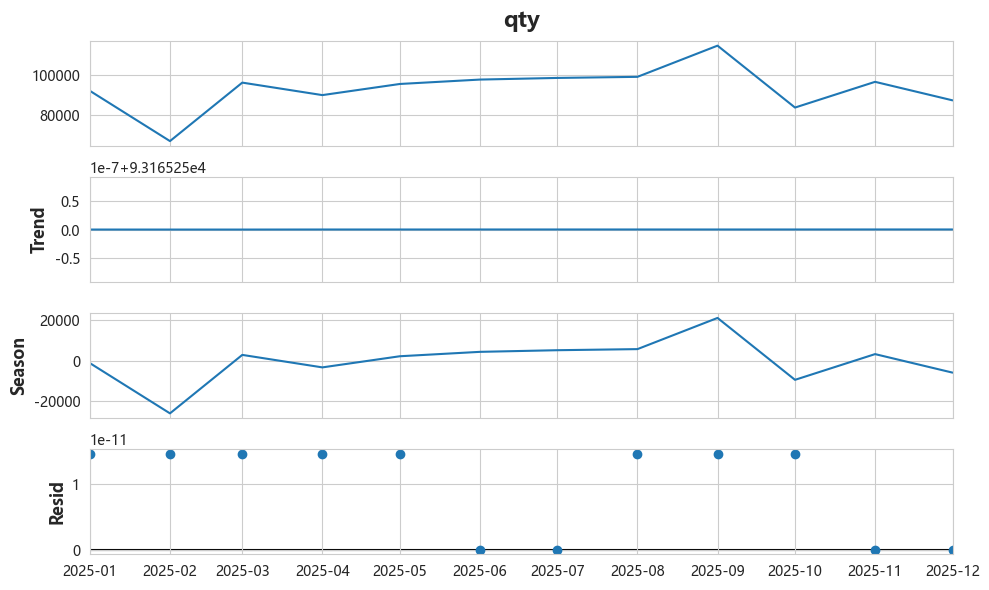

In [20]:
from statsmodels.tsa.seasonal import STL
plt.rc("figure", figsize=(10, 6))

stl = STL(data_2025.set_index('date')['qty'])
result = stl.fit()
result.plot()

seasonal_pattern = result.seasonal
trend_pattern = result.trend

In [21]:
from sklearn.linear_model import LinearRegression
# 计算最近12个月的趋势
recent_data = df_162.tail(12)
if len(recent_data) >= 4:
    X = np.arange(len(recent_data)).reshape(-1, 1)
    y = recent_data['qty'].values
    lr = LinearRegression()
    lr.fit(X, y)
    monthly_growth = lr.coef_[0]
else:
    monthly_growth = 0
print(monthly_growth)

-1614.59965034965


In [22]:
# 生成预测
periods = 6
predictions = []

for i in range(1, periods + 1):
    pred_date = pd.Timestamp(year=2026, month=PRED_MONTH+i, day=1) if PRED_MONTH+i <= 12 else pd.Timestamp(year=2027, month=PRED_MONTH+i-12, day=1)
    pred_month = pred_date.month

    # 趋势分量
    trend_component = base_2026 + monthly_growth * i
    
    # 季节性分量（使用2025年同月的季节性）
    seasonal_idx = pred_month - 1
    seasonal_component = seasonal_pattern.iloc[seasonal_idx]
    
    # 节日调整
    festival_adjustment = 1.0
    # if pred_month == 2:
    #     festival_adjustment = 0.5  # 春节月减半
    # elif pred_month == 1:
    #     festival_adjustment = 1.3  # 春节前月增加30%
    # elif pred_month == 10:
    #     festival_adjustment = 0.6  # 国庆月减少40%
    # elif pred_month == 9:
    #     festival_adjustment = 1.2  # 国庆前月增加20%
    
    forecast = (trend_component + seasonal_component) * festival_adjustment
    forecast = max(0, forecast)  # 确保非负
    
    predictions.append({
        'bizym': pred_date.strftime('%Y%m'),
        'year_month': pred_date.strftime('%Y-%m'),
        'forecast_qty': round(forecast, 2),
        'method': 'STL'
    })

forecast_stl = pd.DataFrame(predictions)
forecast_stl

,bizym,year_month,forecast_qty,method
0,202605,2026-05,96635.86,STL
1,202606,2026-06,97191.76,STL
2,202607,2026-07,96386.16,STL
3,202608,2026-08,95309.56,STL
4,202609,2026-09,109072.46,STL
5,202610,2026-10,76931.86,STL


### 2.4. Phasing

In [23]:
org_data = df_162.copy()
        
# 计算2024年的月度占比
data_2024 = org_data[org_data['year'] == 2024]
total_2024 = data_2024['qty'].sum()
phasing_2024 = data_2024.groupby('month')['qty'].sum() / total_2024

# 计算2025年的月度占比
data_2025 = org_data[org_data['year'] == 2025]
total_2025 = data_2025['qty'].sum()
phasing_2025 = data_2025.groupby('month')['qty'].sum() / total_2025

phasing_2026 = (phasing_2024 + phasing_2025)/2
phasing_2026 = phasing_2026 / phasing_2026.sum()

print(phasing_2025)

month
1     0.082347
2     0.060184
3     0.085978
4     0.080469
5     0.085382
6     0.087323
7     0.088047
8     0.088528
9     0.102283
10    0.074978
11    0.086326
12    0.078155
Name: qty, dtype: float64


In [24]:
# 估算2026年总量
total_2026_estimate = total_2025 * (1 + yearly_growth)

# 生成预测
predictions = []
for month in range(PRED_MONTH+1, periods + PRED_MONTH+1):
    base_forecast = total_2026_estimate * phasing_2025.get(month, 1/12)
    
    # 节日微调
    # if month == 2:
    #     base_forecast *= 0.5
    # elif month == 10:
    #     base_forecast *= 0.6
    
    pred_date = pd.Timestamp(year=2026, month=month, day=1)
    
    predictions.append({
        'bizym': pred_date.strftime('%Y%m'),
        'year_month': pred_date.strftime('%Y-%m'),
        'forecast_qty': round(base_forecast, 2),
        'method': 'Phasing'
    })

forecast_phasing = pd.DataFrame(predictions)
forecast_phasing

,bizym,year_month,forecast_qty,method
0,202605,2026-05,98319.16,Phasing
1,202606,2026-06,100554.78,Phasing
2,202607,2026-07,101388.05,Phasing
3,202608,2026-08,101942.19,Phasing
4,202609,2026-09,117781.02,Phasing
5,202610,2026-10,86339.24,Phasing


### 2.5. MA

In [25]:
org_data = df_162.sort_values('date').copy()
org_data = org_data[org_data['bizym']>=202501]

# 计算移动平均
org_data['ma'] = org_data['qty'].rolling(window=6, min_periods=1).mean()

# 计算季节性指数（同比）
seasonal_index = {}
for month in range(1, 13):
    month_data = org_data[org_data['month'] == month]
    if len(month_data) > 0:
        avg_qty = month_data['qty'].mean()
        overall_avg = org_data['qty'].mean()
        seasonal_index[month] = avg_qty / overall_avg if overall_avg > 0 else 1.0

seasonal_index

{1: np.float64(1.028845108262203),
 2: np.float64(0.74296058131354),
 3: np.float64(0.9996820105440776),
 4: np.float64(0.9883729745323719),
 5: np.float64(1.0478133336717903),
 6: np.float64(1.071638873747895),
 7: np.float64(1.0805192524263418),
 8: np.float64(1.0864248689022435),
 9: np.float64(1.2552234141776646),
 10: np.float64(0.9201400525728846),
 11: np.float64(1.059394049995352),
 12: np.float64(0.959124805201443)}

In [26]:
# 最后一个移动平均值作为基准
last_ma = org_data['ma'].iloc[-1]

# 生成预测
predictions = []
for i in range(PRED_MONTH+1, periods + PRED_MONTH+1):
    pred_date = pd.Timestamp(year=2026, month=i, day=1)
    pred_month = pred_date.month
    
    # 应用季节性指数
    seasonal_factor = seasonal_index.get(pred_month, 1.0)
    forecast = last_ma * seasonal_factor
    
    # 节日调整
    # if pred_month == 2:
    #     forecast *= 0.5
    # elif pred_month == 10:
    #     forecast *= 0.6
    
    forecast = max(0, forecast)
    
    predictions.append({
        'bizym': pred_date.strftime('%Y%m'),
        'year_month': pred_date.strftime('%Y-%m'),
        'forecast_qty': round(forecast, 2),
        'method': 'MovingAvg'
    })

forecast_ma = pd.DataFrame(predictions)
forecast_ma

,bizym,year_month,forecast_qty,method
0,202605,2026-05,91421.54,MovingAvg
1,202606,2026-06,93500.31,MovingAvg
2,202607,2026-07,94275.12,MovingAvg
3,202608,2026-08,94790.39,MovingAvg
4,202609,2026-09,109518.03,MovingAvg
5,202610,2026-10,80282.07,MovingAvg


### 2.6. 集成结果

In [27]:
forecasts = {}
forecasts['STL'] = forecast_stl
forecasts['Phasing'] = forecast_phasing
forecasts['MovingAvg'] = forecast_ma

weights = {'STL': 0.5, 'Phasing': 0.3, 'MovingAvg': 0.2}

# 合并预测结果
all_predictions = []
for month_idx in range(periods):
    month_forecasts = []
    for method, df in forecasts.items():
        if month_idx < len(df):
            month_forecasts.append({
                'method': method,
                'forecast': df.iloc[month_idx]['forecast_qty'],
                'weight': weights.get(method, 0)
            })
    
    if len(month_forecasts) > 0:
        # 加权平均
        weighted_forecast = sum(f['forecast'] * f['weight'] for f in month_forecasts) / sum(f['weight'] for f in month_forecasts)
        
        # 使用第一个预测的日期信息
        first_forecast = list(forecasts.values())[0].iloc[month_idx]
        
        all_predictions.append({
            'bizym': first_forecast['bizym'],
            'year_month': first_forecast['year_month'],
            'forecast_qty': round(weighted_forecast, 2),
            'method': 'Ensemble',
            'methods_used': ','.join([f['method'] for f in month_forecasts])
        })

forecast_ensemble = pd.DataFrame(all_predictions)
forecast_ensemble

,bizym,year_month,forecast_qty,method,methods_used
0,202605,2026-05,96097.99,Ensemble,"STL,Phasing,MovingAvg"
1,202606,2026-06,97462.38,Ensemble,"STL,Phasing,MovingAvg"
2,202607,2026-07,97464.52,Ensemble,"STL,Phasing,MovingAvg"
3,202608,2026-08,97195.52,Ensemble,"STL,Phasing,MovingAvg"
4,202609,2026-09,111774.14,Ensemble,"STL,Phasing,MovingAvg"
5,202610,2026-10,80424.12,Ensemble,"STL,Phasing,MovingAvg"


### 2.7. 可视化观察合理性

In [28]:
df_plot = forecast_ensemble[['bizym', 'forecast_qty']].rename({'forecast_qty':'qty'},axis=1)
df_plot['bizym'] = df_plot['bizym'].astype(int)
df_plot['类型'] = '未来预测值'
df_plot = pd.concat([df_162[['bizym', 'qty']], df_plot])
df_plot.loc[df_plot['类型'].isna(), '类型'] = '历史实际值'
df_plot = df_plot.sort_values('bizym')

df_plot['date'] = pd.to_datetime(df_plot['bizym'], format='%Y%m')
df_plot['year'] = df_plot['date'].dt.year
df_plot['month'] = df_plot['date'].dt.month

df_plot['mom'] = df_plot['qty'].pct_change()
df_plot

,bizym,qty,类型,date,year,month,mom
0,202401,53403.00,历史实际值,2024-01-01,2024,1,NaN
1,202402,38267.25,历史实际值,2024-02-01,2024,2,-0.283425
2,202403,56205.50,历史实际值,2024-03-01,2024,3,0.468762
3,202404,54952.00,历史实际值,2024-04-01,2024,4,-0.022302
4,202405,65626.00,历史实际值,2024-05-01,2024,5,0.194242
5,202406,60242.75,历史实际值,2024-06-01,2024,6,-0.082029
6,202407,62239.00,历史实际值,2024-07-01,2024,7,0.033137
7,202408,67481.00,历史实际值,2024-08-01,2024,8,0.084224
8,202409,74416.00,历史实际值,2024-09-01,2024,9,0.102770
9,202410,52040.00,历史实际值,2024-10-01,2024,10,-0.300688


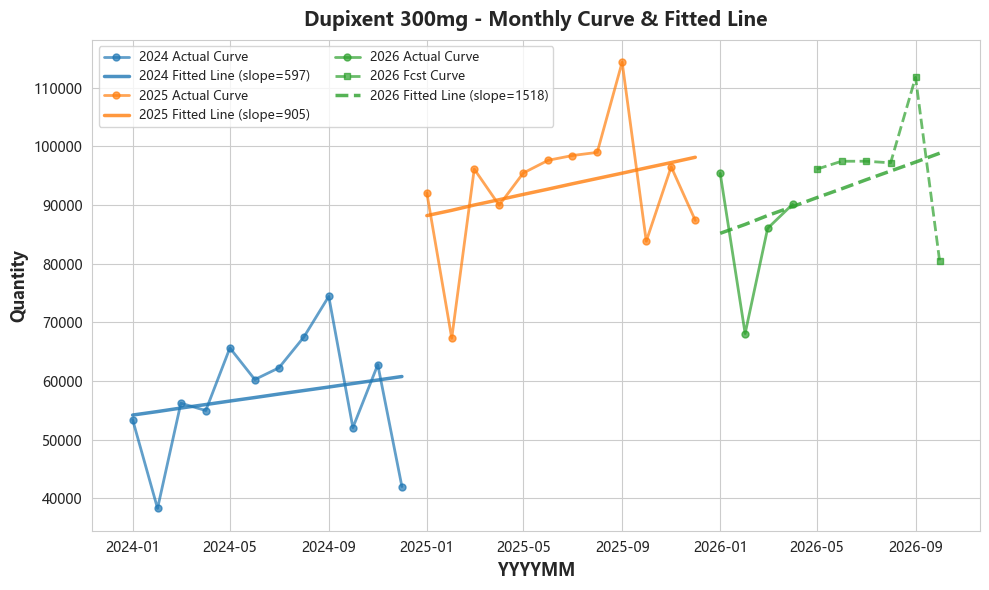

In [29]:
fit_results = {}
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

years = [2024,2025,2026]
for year in years:
    year_df = df_plot[df_plot['year'] == year].copy()
    
    if len(year_df) > 1:
        year_df['年内序号'] = range(len(year_df))
        x_year = year_df['年内序号'].values
        y_year = year_df['qty'].values
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_year, y_year)
        y_fit = slope * x_year + intercept
        
        fit_results[year] = {
            'df': year_df,
            'slope': slope,
            'intercept': intercept,
            'r_value': r_value,
            'y_fit': y_fit,
            'x': x_year,
            'y': y_year
        }

for i, year in enumerate(years):
    year_data = df_plot[df_plot['year'] == year].sort_values('date')
    hist_data = year_data[year_data['类型'] == '历史实际值']
    pred_data_year = year_data[year_data['类型'] == '未来预测值']
    color = colors[i % len(colors)]
    
    if len(hist_data) > 0:
        plt.plot(hist_data['date'], hist_data['qty'], 
                marker='o', linewidth=2, label=f'{year} Actual Curve', 
                color=color, markersize=5, alpha=0.7)
    
    if len(pred_data_year) > 0:
        plt.plot(pred_data_year['date'], pred_data_year['qty'], 
                marker='s', linewidth=2, linestyle='--', label=f'{year} Fcst Curve', 
                color=color, markersize=5, alpha=0.7)
    
    if year in fit_results:
        result = fit_results[year]
        has_pred = (year_data['类型'] == '未来预测值').any()
        line_style = '--' if has_pred else '-'
        
        plt.plot(result['df']['date'], result['y_fit'], 
                linestyle=line_style, linewidth=2.5, color=color, 
                label=f'{year} Fitted Line (slope={result["slope"]:.0f})',
                alpha=0.8)

plt.xlabel('YYYYMM', fontsize=12, fontweight='bold')
plt.ylabel('Quantity', fontsize=12, fontweight='bold')
plt.title('Dupixent 300mg - Monthly Curve & Fitted Line', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

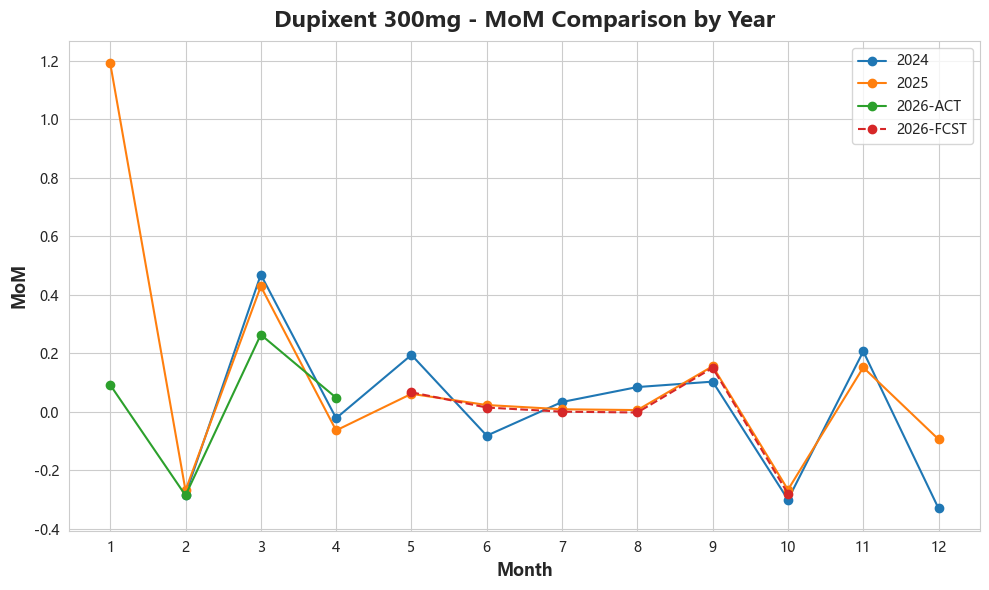

In [30]:
for y in years:
    sub = df_plot[df_plot["year"] == y].sort_values("month")
    if y==2026:
        plt.plot(sub[sub['类型'] == '历史实际值']["month"], sub[sub['类型'] == '历史实际值']["mom"], label=str(y)+'-ACT', marker='o')
        plt.plot(sub[sub['类型'] == '未来预测值']["month"], sub[sub['类型'] == '未来预测值']["mom"], label=str(y)+'-FCST', marker='o',linestyle='--')
    else:
        plt.plot(sub["month"], sub["mom"], label=str(y), marker='o')

plt.xlabel("Month")
plt.ylabel("MoM")
plt.title("Dupixent 300mg - MoM Comparison by Year")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

## 3. 169规格预测

### 3.1. 数据准备

In [31]:
df_169 = df_raw[df_raw['prodmdmcode']==169]
df_169 = df_169[(df_169['bizym']>=202401) & (df_169['bizym']<=202604)]
df_169 = df_169.groupby(['bizym'])['qty'].sum().reset_index()

In [32]:
df_169['date'] = pd.to_datetime(df_169['bizym'], format='%Y%m')
df_169['year'] = df_169['date'].dt.year
df_169['month'] = df_169['date'].dt.month
df_169['year_month'] = df_169['date'].dt.strftime('%Y-%m')

In [33]:
PRED_MONTH = df_169['month'].values[-1]

In [34]:
# 分段数据
data_2024 = df_169[df_169['year'] == 2024]
data_2025 = df_169[df_169['year'] == 2025]
data_2026 = df_169[df_169['year'] == 2026]

### 3.2. 2026基准假设

In [35]:
# 计算水平跃迁
level_2024 = data_2024['qty'].mean() if len(data_2024) > 0 else 0
level_2025 = data_2025['qty'].mean() if len(data_2025) > 0 else level_2024
print(f"25对比24增长率：{(level_2025 / level_2024 - 1) * 100:.1f}%")

25对比24增长率：72.3%


In [36]:
print(f"26Q1同比增长率：{(data_2026[data_2026['month'].isin([1,2,3])]['qty'].sum() / data_2025[data_2025['month'].isin([1,2,3])]['qty'].sum() - 1) * 100:.1f}%")

26Q1同比增长率：35.3%


In [37]:
# 估算2026年基准
yearly_growth = 0.3
base_2026 = level_2025 * (1+yearly_growth)
base_2026

np.float64(9086.43125)

### 3.3. STL

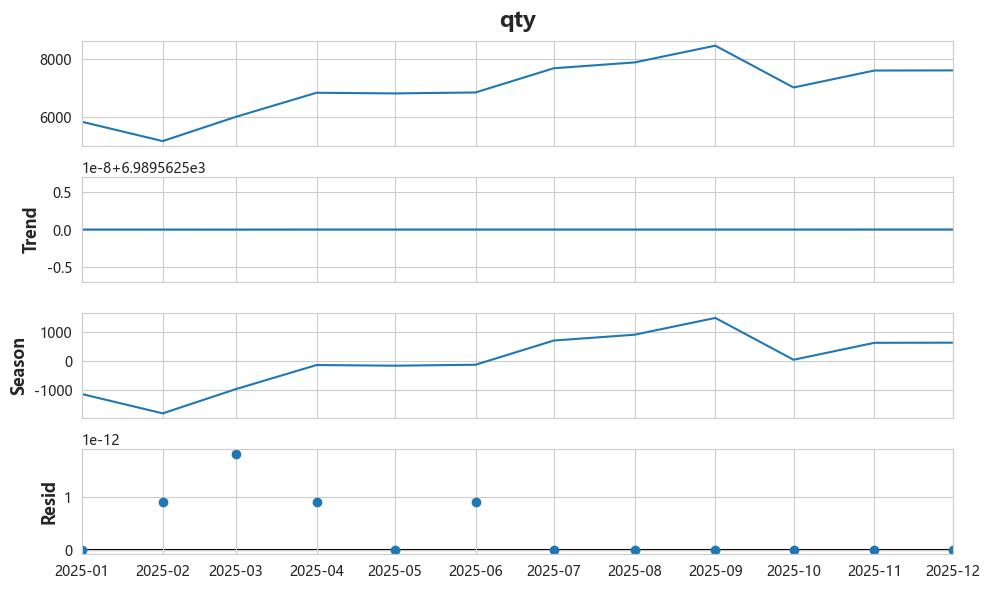

In [38]:
from statsmodels.tsa.seasonal import STL
plt.rc("figure", figsize=(10, 6))

stl = STL(data_2025.set_index('date')['qty'])
result = stl.fit()
result.plot()

seasonal_pattern = result.seasonal
trend_pattern = result.trend

In [39]:
from sklearn.linear_model import LinearRegression
# 计算最近12个月的趋势
recent_data = df_169.tail(12)
if len(recent_data) >= 4:
    X = np.arange(len(recent_data)).reshape(-1, 1)
    y = recent_data['qty'].values
    lr = LinearRegression()
    lr.fit(X, y)
    monthly_growth = lr.coef_[0]
else:
    monthly_growth = 0
print(monthly_growth)

101.61013986013982


In [40]:
# 生成预测
periods = 6
predictions = []

for i in range(1, periods + 1):
    pred_date = pd.Timestamp(year=2026, month=PRED_MONTH+i, day=1) if PRED_MONTH+i <= 12 else pd.Timestamp(year=2027, month=PRED_MONTH+i-12, day=1)
    pred_month = pred_date.month

    # 趋势分量
    trend_component = base_2026 + monthly_growth * i
    
    # 季节性分量（使用2025年同月的季节性）
    seasonal_idx = pred_month - 1
    seasonal_component = seasonal_pattern.iloc[seasonal_idx]
    
    # 节日调整
    festival_adjustment = 1.0
    # if pred_month == 2:
    #     festival_adjustment = 0.5  # 春节月减半
    # elif pred_month == 1:
    #     festival_adjustment = 1.3  # 春节前月增加30%
    # elif pred_month == 10:
    #     festival_adjustment = 0.6  # 国庆月减少40%
    # elif pred_month == 9:
    #     festival_adjustment = 1.2  # 国庆前月增加20%
    
    forecast = (trend_component + seasonal_component) * festival_adjustment
    forecast = max(0, forecast)  # 确保非负
    
    predictions.append({
        'bizym': pred_date.strftime('%Y%m'),
        'year_month': pred_date.strftime('%Y-%m'),
        'forecast_qty': round(forecast, 2),
        'method': 'STL'
    })

forecast_stl = pd.DataFrame(predictions)
forecast_stl

,bizym,year_month,forecast_qty,method
0,202605,2026-05,9022.98,STL
1,202606,2026-06,9157.09,STL
2,202607,2026-07,10087.70,STL
3,202608,2026-08,10389.31,STL
4,202609,2026-09,11065.42,STL
5,202610,2026-10,9734.03,STL


### 3.4. Phasing

In [41]:
org_data = df_169.copy()
        
# 计算2024年的月度占比
data_2024 = org_data[org_data['year'] == 2024]
total_2024 = data_2024['qty'].sum()
phasing_2024 = data_2024.groupby('month')['qty'].sum() / total_2024

# 计算2025年的月度占比
data_2025 = org_data[org_data['year'] == 2025]
total_2025 = data_2025['qty'].sum()
phasing_2025 = data_2025.groupby('month')['qty'].sum() / total_2025

phasing_2026 = (phasing_2024 + phasing_2025)/2
phasing_2026 = phasing_2026 / phasing_2026.sum()

print(phasing_2025)

month
1     0.069783
2     0.061893
3     0.071780
4     0.081634
5     0.081365
6     0.081753
7     0.091637
8     0.094021
9     0.100871
10    0.083786
11    0.090713
12    0.090766
Name: qty, dtype: float64


In [42]:
# 估算2026年总量
total_2026_estimate = total_2025 * (1 + yearly_growth)

# 生成预测
predictions = []
for month in range(PRED_MONTH+1, periods + PRED_MONTH+1):
    base_forecast = total_2026_estimate * phasing_2025.get(month, 1/12)
    
    # 节日微调
    # if month == 2:
    #     base_forecast *= 0.5
    # elif month == 10:
    #     base_forecast *= 0.6
    
    pred_date = pd.Timestamp(year=2026, month=month, day=1)
    
    predictions.append({
        'bizym': pred_date.strftime('%Y%m'),
        'year_month': pred_date.strftime('%Y-%m'),
        'forecast_qty': round(base_forecast, 2),
        'method': 'Phasing'
    })

forecast_phasing = pd.DataFrame(predictions)
forecast_phasing

,bizym,year_month,forecast_qty,method
0,202605,2026-05,8871.85,Phasing
1,202606,2026-06,8914.10,Phasing
2,202607,2026-07,9991.80,Phasing
3,202608,2026-08,10251.80,Phasing
4,202609,2026-09,10998.65,Phasing
5,202610,2026-10,9135.75,Phasing


### 3.5. MA

In [43]:
org_data = df_169.sort_values('date').copy()
org_data = org_data[org_data['bizym']>=202501]

# 计算移动平均
org_data['ma'] = org_data['qty'].rolling(window=6, min_periods=1).mean()

# 计算季节性指数（同比）
seasonal_index = {}
for month in range(1, 13):
    month_data = org_data[org_data['month'] == month]
    if len(month_data) > 0:
        avg_qty = month_data['qty'].mean()
        overall_avg = org_data['qty'].mean()
        seasonal_index[month] = avg_qty / overall_avg if overall_avg > 0 else 1.0

seasonal_index

{1: np.float64(0.9652892276987868),
 2: np.float64(0.824644325041974),
 3: np.float64(0.979324406166685),
 4: np.float64(1.0951577341118202),
 5: np.float64(0.9413570069206016),
 6: np.float64(0.9458399877580139),
 7: np.float64(1.0601904835800051),
 8: np.float64(1.0877780579640801),
 9: np.float64(1.1670233653823359),
 10: np.float64(0.9693583949204378),
 11: np.float64(1.0495002985061759),
 12: np.float64(1.0501210189298176)}

In [44]:
# 最后一个移动平均值作为基准
last_ma = org_data['ma'].iloc[-1]

# 生成预测
predictions = []
for i in range(PRED_MONTH+1, periods + PRED_MONTH+1):
    pred_date = pd.Timestamp(year=2026, month=i, day=1)
    pred_month = pred_date.month
    
    # 应用季节性指数
    seasonal_factor = seasonal_index.get(pred_month, 1.0)
    forecast = last_ma * seasonal_factor
    
    # 节日调整
    # if pred_month == 2:
    #     forecast *= 0.5
    # elif pred_month == 10:
    #     forecast *= 0.6
    
    forecast = max(0, forecast)
    
    predictions.append({
        'bizym': pred_date.strftime('%Y%m'),
        'year_month': pred_date.strftime('%Y-%m'),
        'forecast_qty': round(forecast, 2),
        'method': 'MovingAvg'
    })

forecast_ma = pd.DataFrame(predictions)
forecast_ma

,bizym,year_month,forecast_qty,method
0,202605,2026-05,7427.46,MovingAvg
1,202606,2026-06,7462.84,MovingAvg
2,202607,2026-07,8365.08,MovingAvg
3,202608,2026-08,8582.75,MovingAvg
4,202609,2026-09,9208.01,MovingAvg
5,202610,2026-10,7648.40,MovingAvg


### 3.6. 集成结果

In [45]:
forecasts = {}
forecasts['STL'] = forecast_stl
forecasts['Phasing'] = forecast_phasing
forecasts['MovingAvg'] = forecast_ma

weights = {'STL': 0.5, 'Phasing': 0.3, 'MovingAvg': 0.2}

# 合并预测结果
all_predictions = []
for month_idx in range(periods):
    month_forecasts = []
    for method, df in forecasts.items():
        if month_idx < len(df):
            month_forecasts.append({
                'method': method,
                'forecast': df.iloc[month_idx]['forecast_qty'],
                'weight': weights.get(method, 0)
            })
    
    if len(month_forecasts) > 0:
        # 加权平均
        weighted_forecast = sum(f['forecast'] * f['weight'] for f in month_forecasts) / sum(f['weight'] for f in month_forecasts)
        
        # 使用第一个预测的日期信息
        first_forecast = list(forecasts.values())[0].iloc[month_idx]
        
        all_predictions.append({
            'bizym': first_forecast['bizym'],
            'year_month': first_forecast['year_month'],
            'forecast_qty': round(weighted_forecast, 2),
            'method': 'Ensemble',
            'methods_used': ','.join([f['method'] for f in month_forecasts])
        })

forecast_ensemble = pd.DataFrame(all_predictions)
forecast_ensemble

,bizym,year_month,forecast_qty,method,methods_used
0,202605,2026-05,8658.54,Ensemble,"STL,Phasing,MovingAvg"
1,202606,2026-06,8745.34,Ensemble,"STL,Phasing,MovingAvg"
2,202607,2026-07,9714.41,Ensemble,"STL,Phasing,MovingAvg"
3,202608,2026-08,9986.74,Ensemble,"STL,Phasing,MovingAvg"
4,202609,2026-09,10673.91,Ensemble,"STL,Phasing,MovingAvg"
5,202610,2026-10,9137.42,Ensemble,"STL,Phasing,MovingAvg"


### 3.7. 可视化观察合理性

In [46]:
df_plot = forecast_ensemble[['bizym', 'forecast_qty']].rename({'forecast_qty':'qty'},axis=1)
df_plot['bizym'] = df_plot['bizym'].astype(int)
df_plot['类型'] = '未来预测值'
df_plot = pd.concat([df_169[['bizym', 'qty']], df_plot])
df_plot.loc[df_plot['类型'].isna(), '类型'] = '历史实际值'
df_plot = df_plot.sort_values('bizym')

df_plot['date'] = pd.to_datetime(df_plot['bizym'], format='%Y%m')
df_plot['year'] = df_plot['date'].dt.year
df_plot['month'] = df_plot['date'].dt.month

df_plot['mom'] = df_plot['qty'].pct_change()
df_plot

,bizym,qty,类型,date,year,month,mom
0,202401,2860.50,历史实际值,2024-01-01,2024,1,NaN
1,202402,2817.00,历史实际值,2024-02-01,2024,2,-0.015207
2,202403,3474.00,历史实际值,2024-03-01,2024,3,0.233227
3,202404,3747.00,历史实际值,2024-04-01,2024,4,0.078584
4,202405,4161.50,历史实际值,2024-05-01,2024,5,0.110622
5,202406,3869.00,历史实际值,2024-06-01,2024,6,-0.070287
6,202407,5030.00,历史实际值,2024-07-01,2024,7,0.300078
7,202408,5452.50,历史实际值,2024-08-01,2024,8,0.083996
8,202409,5105.75,历史实际值,2024-09-01,2024,9,-0.063595
9,202410,4149.50,历史实际值,2024-10-01,2024,10,-0.187289


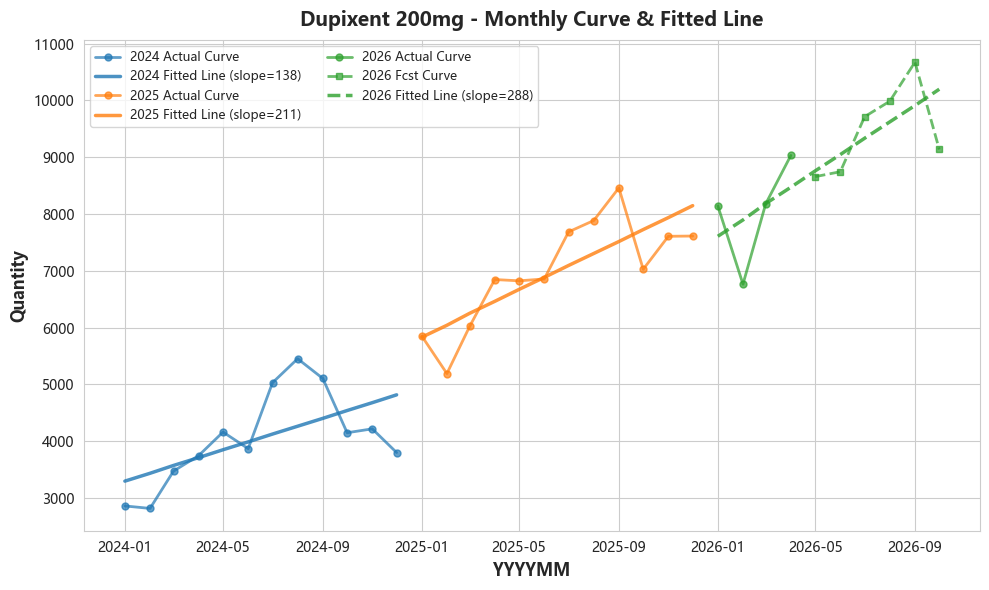

In [47]:
fit_results = {}
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

years = [2024,2025,2026]
for year in years:
    year_df = df_plot[df_plot['year'] == year].copy()
    
    if len(year_df) > 1:
        year_df['年内序号'] = range(len(year_df))
        x_year = year_df['年内序号'].values
        y_year = year_df['qty'].values
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_year, y_year)
        y_fit = slope * x_year + intercept
        
        fit_results[year] = {
            'df': year_df,
            'slope': slope,
            'intercept': intercept,
            'r_value': r_value,
            'y_fit': y_fit,
            'x': x_year,
            'y': y_year
        }

for i, year in enumerate(years):
    year_data = df_plot[df_plot['year'] == year].sort_values('date')
    hist_data = year_data[year_data['类型'] == '历史实际值']
    pred_data_year = year_data[year_data['类型'] == '未来预测值']
    color = colors[i % len(colors)]
    
    if len(hist_data) > 0:
        plt.plot(hist_data['date'], hist_data['qty'], 
                marker='o', linewidth=2, label=f'{year} Actual Curve', 
                color=color, markersize=5, alpha=0.7)
    
    if len(pred_data_year) > 0:
        plt.plot(pred_data_year['date'], pred_data_year['qty'], 
                marker='s', linewidth=2, linestyle='--', label=f'{year} Fcst Curve', 
                color=color, markersize=5, alpha=0.7)
    
    if year in fit_results:
        result = fit_results[year]
        has_pred = (year_data['类型'] == '未来预测值').any()
        line_style = '--' if has_pred else '-'
        
        plt.plot(result['df']['date'], result['y_fit'], 
                linestyle=line_style, linewidth=2.5, color=color, 
                label=f'{year} Fitted Line (slope={result["slope"]:.0f})',
                alpha=0.8)

plt.xlabel('YYYYMM', fontsize=12, fontweight='bold')
plt.ylabel('Quantity', fontsize=12, fontweight='bold')
plt.title('Dupixent 200mg - Monthly Curve & Fitted Line', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

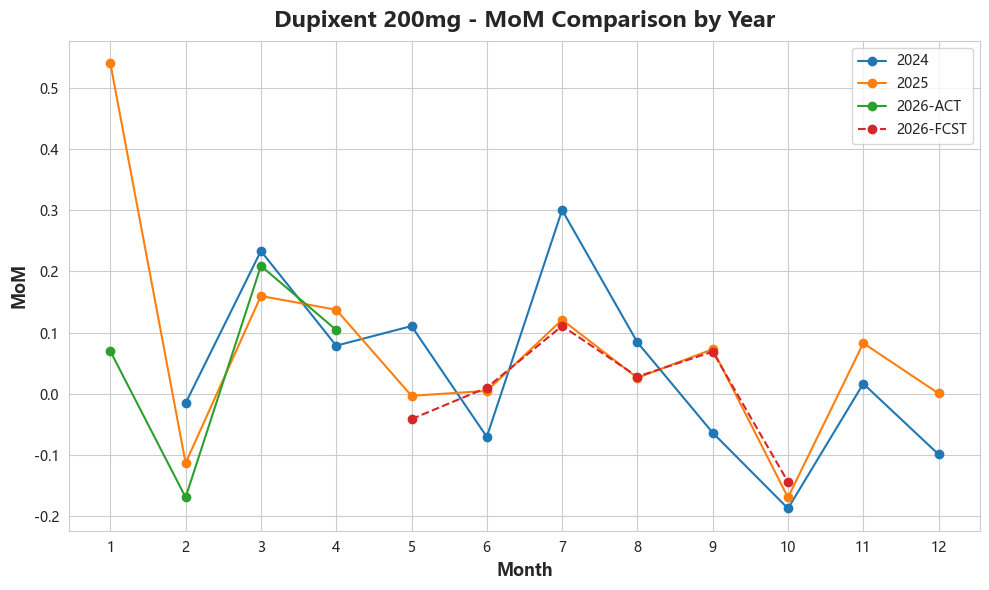

In [48]:
for y in years:
    sub = df_plot[df_plot["year"] == y].sort_values("month")
    if y==2026:
        plt.plot(sub[sub['类型'] == '历史实际值']["month"], sub[sub['类型'] == '历史实际值']["mom"], label=str(y)+'-ACT', marker='o')
        plt.plot(sub[sub['类型'] == '未来预测值']["month"], sub[sub['类型'] == '未来预测值']["mom"], label=str(y)+'-FCST', marker='o',linestyle='--')
    else:
        plt.plot(sub["month"], sub["mom"], label=str(y), marker='o')

plt.xlabel("Month")
plt.ylabel("MoM")
plt.title("Dupixent 200mg - MoM Comparison by Year")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()